In [1]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score





---
# 2️⃣ Load & Explore Data

---

### 🔗 ربط بالخطوة السابقة
دلوقتي عندنا كل الأدوات جاهزة — الخطوة الجاية هي نجيب البيانات ونبدأ نفهمها.

---

### 📖 النظرية
**House Prices Dataset** فيه **79 features** تصف بيوت في Ames, Iowa.

أنواع الـ features:
- **Numeric:** زي LotArea, GrLivArea, GarageArea
- **Categorical:** زي MSZoning, Street, Neighborhood
- **Ordinal:** زي OverallQual, OverallCond (لها ترتيب)

**الـ Target:** `SalePrice` — سعر البيت بالدولار

> 💡 **قاعدة ذهبية:** في Regression، لازم تفهم توزيع الـ target كويس — هل طبيعي ولا skewed؟

---

### 🤔 فكر قبل ما تكتب
- إيه الفرق بين Categorical و Ordinal features؟
- ليه Missing Values مشكلة أكبر في البيانات دي من Breast Cancer؟
- إيه تتوقع إن أهم feature تأثر في سعر البيت؟

---

### ⚠️ Common Mistakes
```
❌ غلط: تتعامل مع كل Missing Values بنفس الطريقة.
✅ صح: فيه missing values معناها "مش موجود" (زي GarageType)،
     وفيه missing values معناها "بيانات ناقصة".

❌ غلط: تتجاهل الـ categorical features.
✅ صح: الـ categorical features مهمة جداً في تحديد سعر البيت.
```

---

### 🎯 المطلوب منك
1. حمّل البيانات من `train.csv` و `test.csv`
2. اطبع الـ shape والـ info
3. تحقق من الـ missing values في كل column
4. اطبع statistical summary للـ numeric features
5. اطبع عدد الـ categorical features

In [2]:
#  Load & Explore Data
df=pd.read_csv('/content/sample_data/california_housing_train.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [3]:
df.isnull().sum()
# there are no null values

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [4]:
numeric_summary = df.describe()
print(numeric_summary)
# الارقام كارثيه

          longitude      latitude  housing_median_age   total_rooms  \
count  17000.000000  17000.000000        17000.000000  17000.000000   
mean    -119.562108     35.625225           28.589353   2643.664412   
std        2.005166      2.137340           12.586937   2179.947071   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.790000     33.930000           18.000000   1462.000000   
50%     -118.490000     34.250000           29.000000   2127.000000   
75%     -118.000000     37.720000           37.000000   3151.250000   
max     -114.310000     41.950000           52.000000  37937.000000   

       total_bedrooms    population    households  median_income  \
count    17000.000000  17000.000000  17000.000000   17000.000000   
mean       539.410824   1429.573941    501.221941       3.883578   
std        421.499452   1147.852959    384.520841       1.908157   
min          1.000000      3.000000      1.000000       0.499900   
25%        297.00000

In [5]:
categorical_features = df.select_dtypes(include=['object', 'category']).columns
print(f"Number of categorical features: {len(categorical_features)}")
print(f"Names: {list(categorical_features)}")

Number of categorical features: 0
Names: []


---
# 3️⃣ EDA & Visualization 🔍

---

### 🔗 ربط بالخطوة السابقة
عرفنا إن البيانات فيها missing values و categorical features كتير —  
دلوقتي هنتعمق أكتر ونشوف العلاقات بين الـ features والـ target.

---

### 📖 النظرية
الـ Visualization في Regression مختلفة عن Classification:

| نوع الـ Plot | بيجاوب على سؤال |
|-------------|----------------|
| `Histplot` (Target) | الـ target طبيعي ولا skewed؟ |
| `Scatter Plot` | العلاقة بين feature والـ target |
| `Boxplot` | تأثير الـ categorical feature على السعر |
| `Heatmap` | الـ correlation بين الـ features |
| `QQ Plot` | هل التوزيع طبيعي؟ |

> 💡 **مهم:** لو الـ target skewed، ممكن نعمل log transformation!

---

### 🤔 فكر قبل ما تكتب
- لو الـ SalePrice skewed، إيه تأثير ده على الموديل؟
- إيه الفرق بين correlation و causation؟
- إزاي تعرف إن feature مهمة من الـ scatter plot؟

---

### ⚠️ Common Mistakes
```
❌ غلط: تعمل model على target skewed من غير transformation.
✅ صح: اعمل log transform للـ target لو skewed، وبعدين ارجعها exp عشان الـ submission.

❌ غلط: تحسب correlation مع الـ target بس وتشيل الباقي.
✅ صح: شوف multicollinearity بين الـ features كمان.
```

---

### 🎯 المطلوب منك

**3.1 — Target Distribution**  
ارسم histogram للـ SalePrice. هل طبيعي ولا skewed؟

**3.2 — Log Transformation**  
لو skewed، ارسم histogram بعد log1p transformation.

**3.3 — Correlation Heatmap**  
ارسم heatmap لأعلى 15 feature مرتبطة بالـ SalePrice.

**3.4 — Scatter Plots**  
ارسم scatter plots لأهم 3 numeric features مع الـ SalePrice.

**3.5 — Categorical Analysis**  
ارسم boxplots لـ 2 categorical features مهمين (زي OverallQual, Neighborhood).

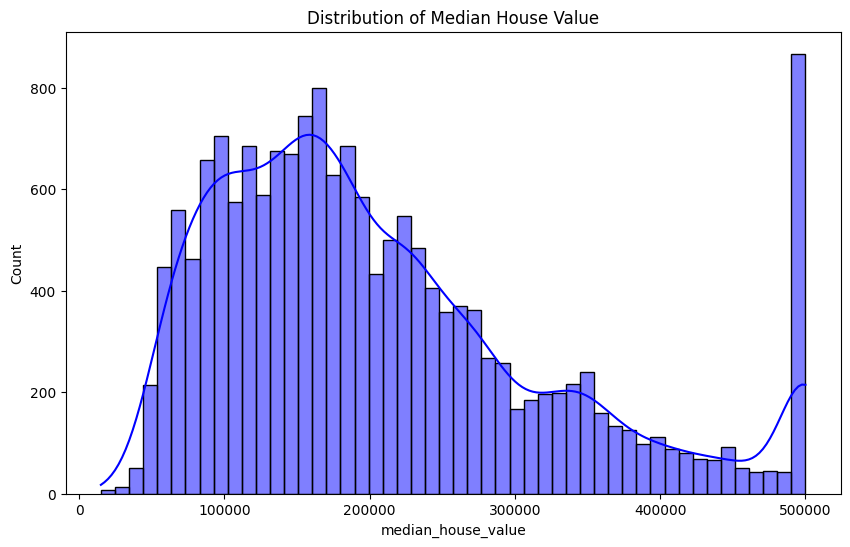

In [22]:
# Target Distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='blue')
plt.title('Distribution of Median House Value')
plt.show()


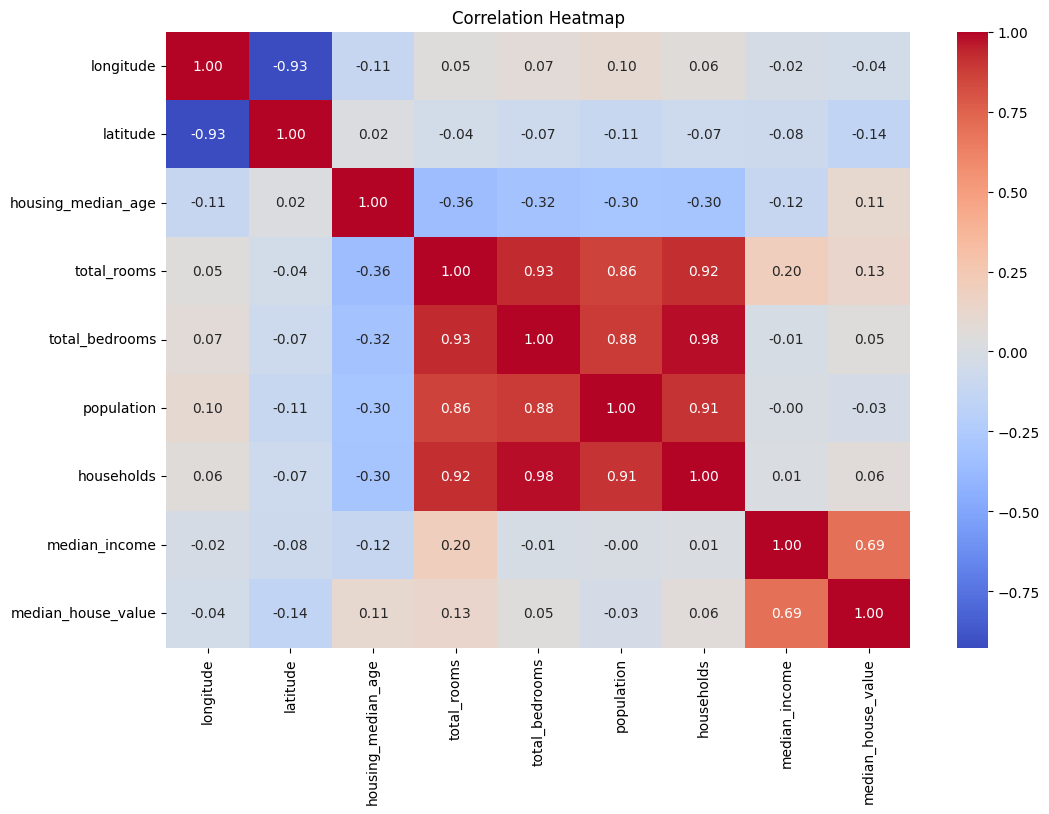

In [24]:
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()
#meadian income have the big impact on house price

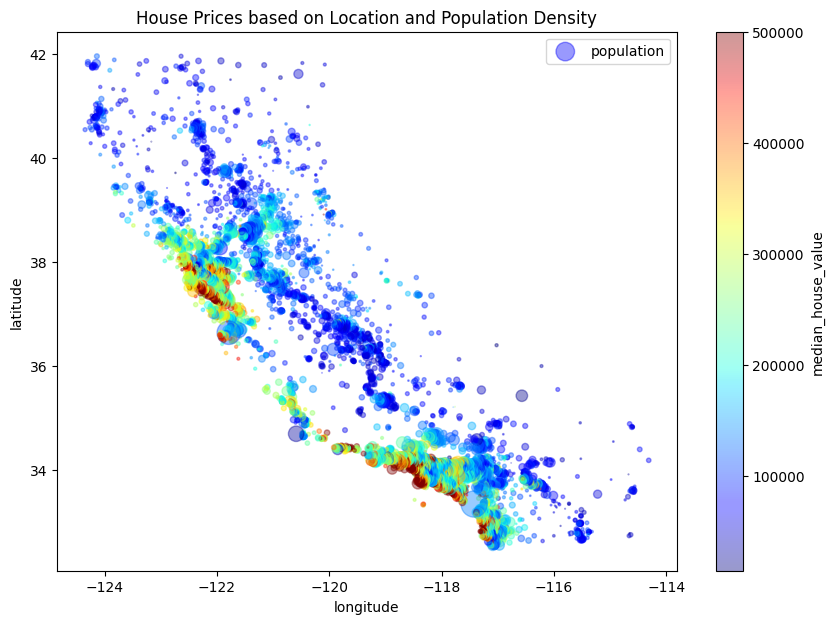

In [25]:
df.plot(kind="scatter", x="longitude", y="latitude", alpha=0.4,
        s=df["population"]/100, label="population", figsize=(10,7),
        c="median_house_value", cmap=plt.get_cmap("jet"), colorbar=True,
)
plt.title('House Prices based on Location and Population Density')
plt.legend()
plt.show()

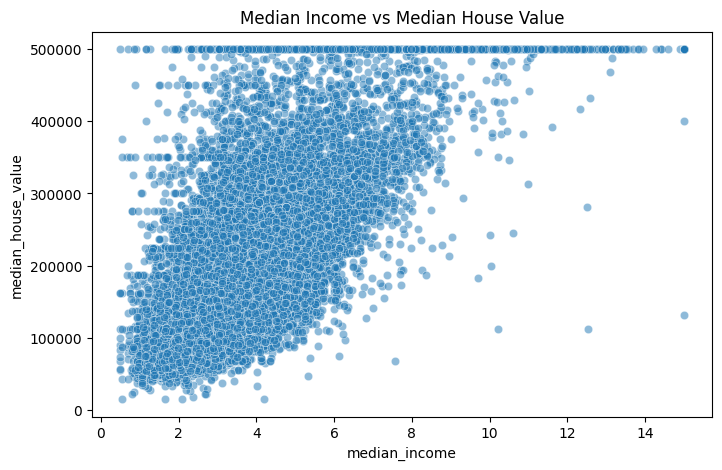

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='median_income', y='median_house_value', alpha=0.5)
plt.title('Median Income vs Median House Value')
plt.show()

In [28]:

df = df[df['median_house_value'] < 500000]

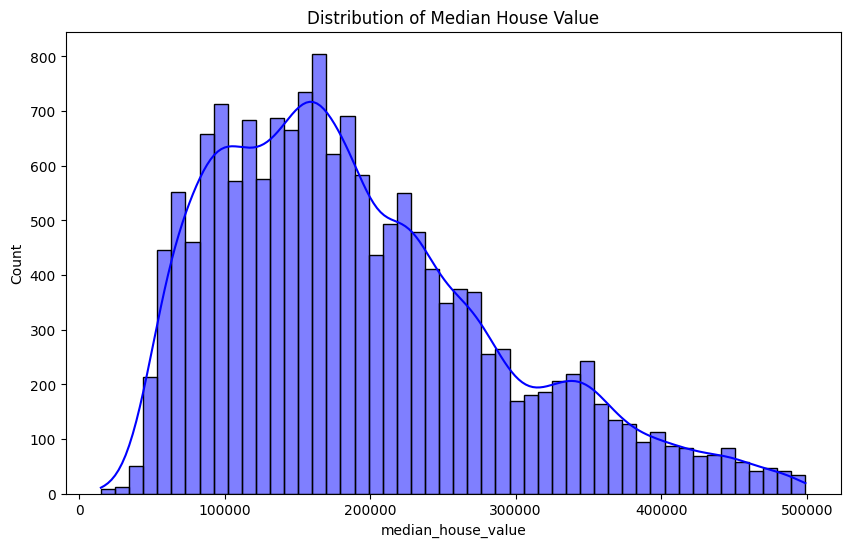

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['median_house_value'], bins=50, kde=True, color='blue')
plt.title('Distribution of Median House Value')
plt.show()

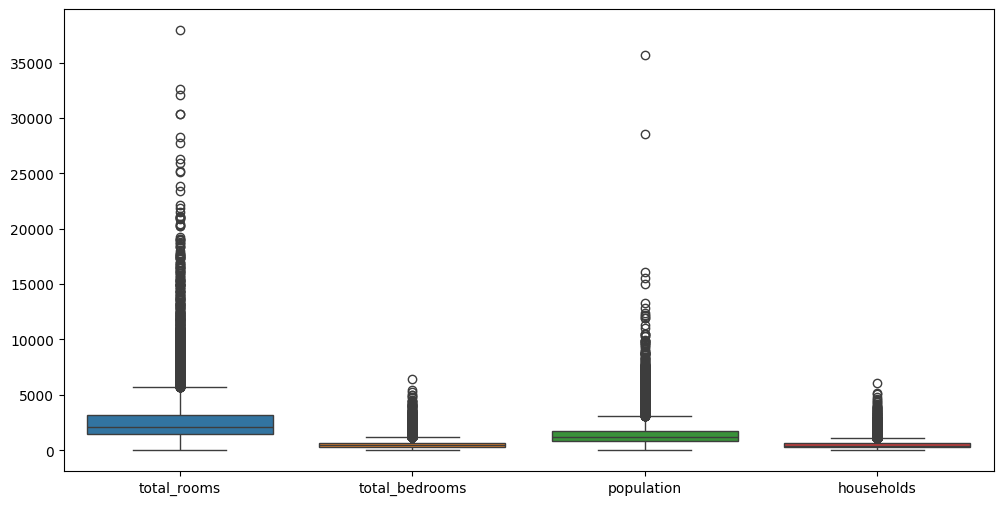

In [27]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['total_rooms', 'total_bedrooms', 'population', 'households']])
plt.show()

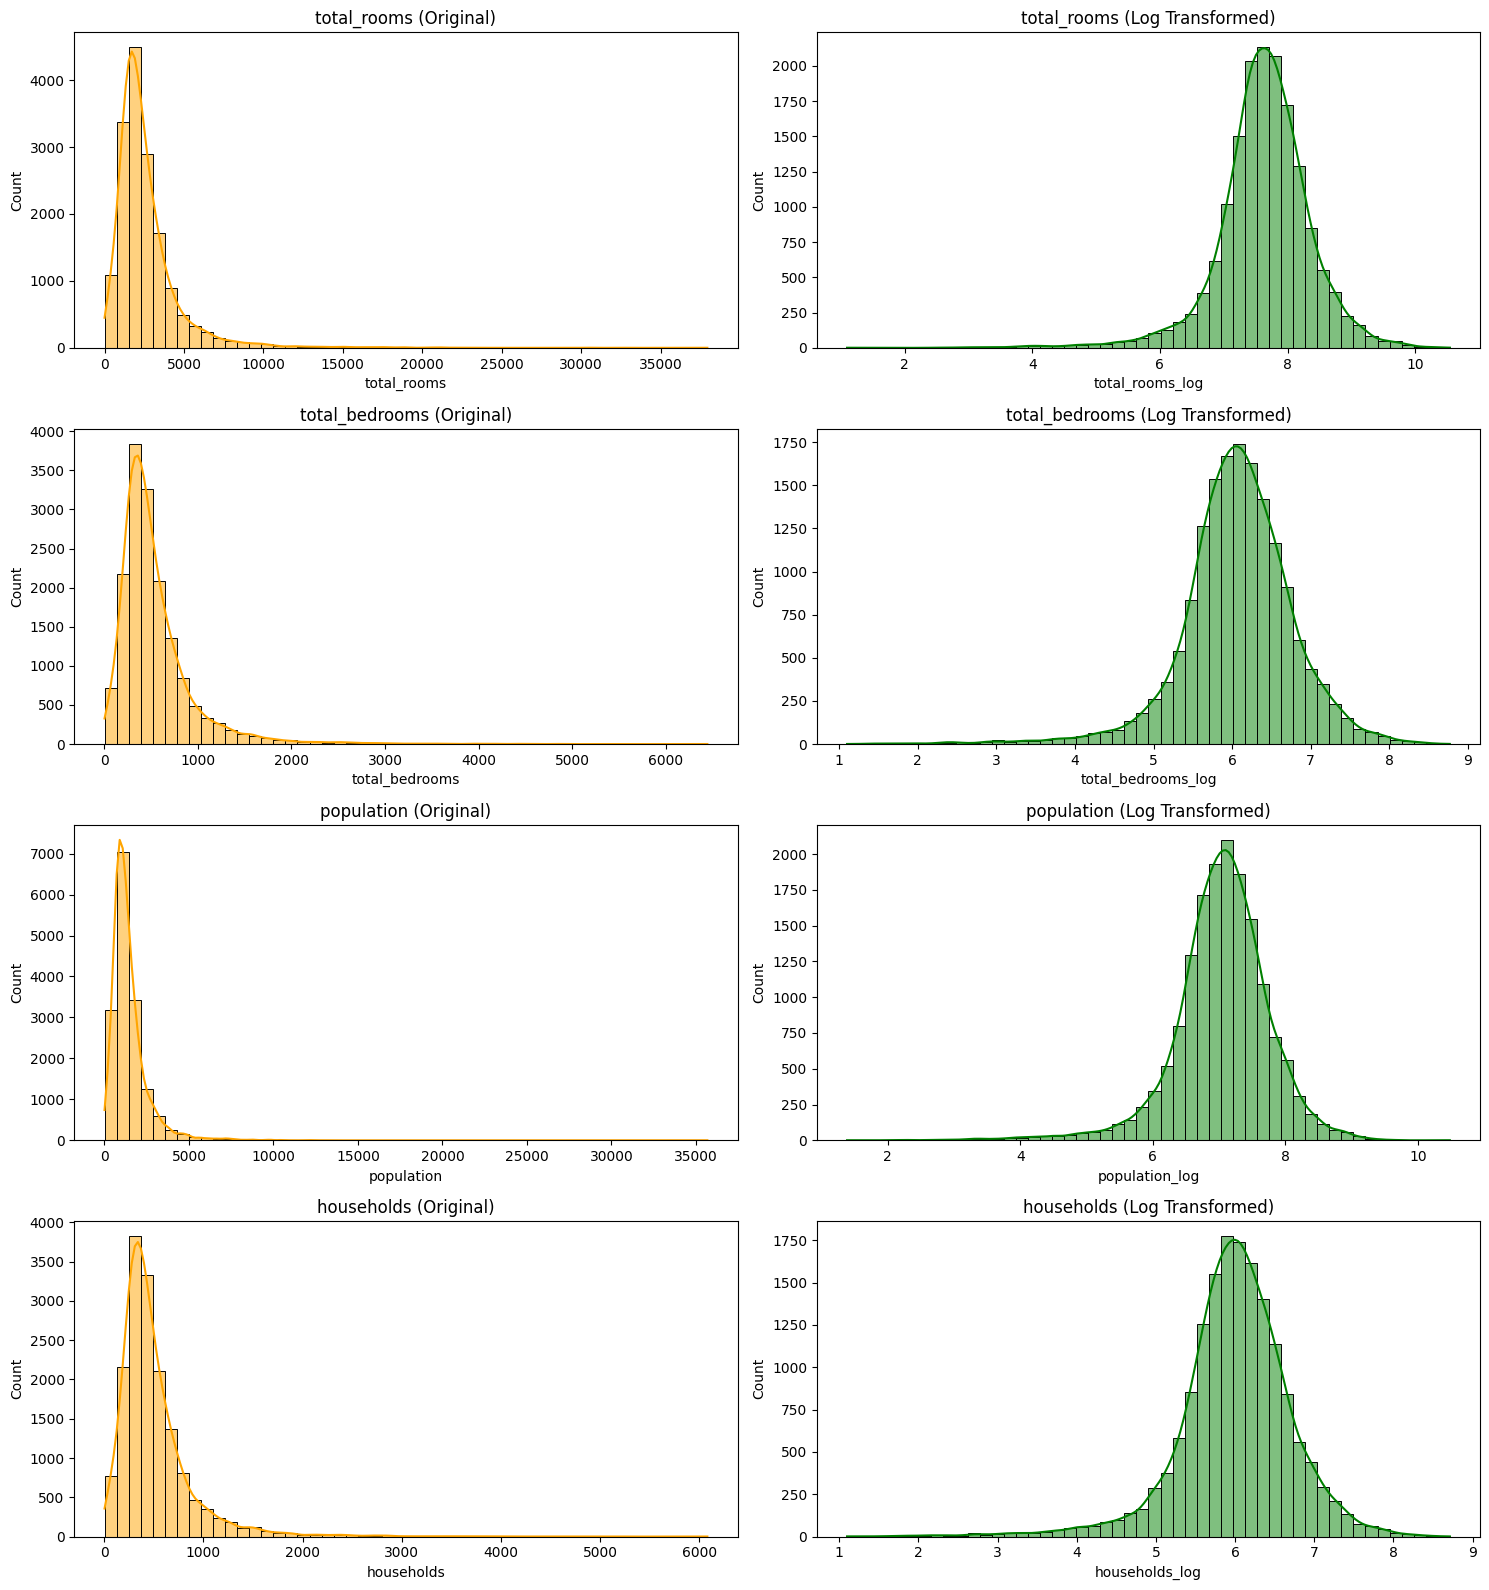

In [35]:

#Log Transformation
cols_to_transform = ['total_rooms', 'total_bedrooms', 'population', 'households']

fig, axes = plt.subplots(4, 2, figsize=(15, 16))

for i, col in enumerate(cols_to_transform):
    df[f'{col}_log'] = np.log1p(df[col])

    sns.histplot(df[col], bins=50, kde=True, ax=axes[i, 0], color='orange')
    axes[i, 0].set_title(f'{col} (Original)')

    sns.histplot(df[f'{col}_log'], bins=50, kde=True, ax=axes[i, 1], color='green')
    axes[i, 1].set_title(f'{col} (Log Transformed)')

plt.tight_layout()
plt.show()

In [37]:
real_income = df['median_income'] * 10000
print(real_income.describe())


count     16164.000000
mean      36849.926875
std       15771.084525
min        4999.000000
25%       25259.000000
50%       34583.000000
75%       46006.250000
max      150001.000000
Name: median_income, dtype: float64


---
# 4️⃣ Feature Engineering 🛠️

---

### 🔗 ربط بالخطوة السابقة
من الـ EDA لقينا إن فيه missing values، categorical features، و skewed target —  
دلوقتي هنجهز البيانات للـ modeling.

---

### 📖 النظرية
**Feature Engineering في Regression:**

| الخطوة | الهدف |
|--------|-------|
| **Handle Missing Values** | ملء أو حذف البيانات الناقصة |
| **Encode Categorical** | تحويل الـ categories لـ numbers |
| **Create New Features** | إنشاء features جديدة مفيدة |
| **Remove Outliers** | حذف أو معالجة القيم الشاذة |
| **Transform Target** | تطبيق log على الـ target |

> 💡 **قاعدة:** Feature Engineering الكويس ممكن يحسن الـ score أكتر من الـ model نفسه!

---

### 🤔 فكر قبل ما تكتب
- إيه الفرق بين Label Encoding و One-Hot Encoding؟
- إمتى تملأ missing value بالـ mean وإمتى بالـ mode؟
- إيه الـ feature engineering اللي ممكن تعمله من domain knowledge؟

---

### ⚠️ Common Mistakes
```
❌ غلط: تعمل One-Hot Encoding لكل الـ categorical features.
✅ صح: لو feature ليه كتير categories، استخدم Label Encoding أو Frequency Encoding.

❌ غلط: تعمل fillna بالـ mean على كل الـ numeric columns.
✅ صح: فيه columns الـ NaN معناها "مش موجود" (زي GarageYrBlt).

❌ غلط: تعمل preprocessing على train و test منفصل.
✅ صح: ادمجهم، اعمل preprocessing، وبعدين افصلهم تاني.
```

---

### 🎯 المطلوب منك

**4.1 — Handle Missing Values**  
املأ الـ missing values بالطريقة المناسبة لكل column.

**4.2 — Encode Categorical Features**  
حوّل الـ categorical features لـ numeric.

**4.3 — Create New Features**  
ابتكر features جديدة (زي TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF).

**4.4 — Handle Outliers**  
احذف أو عالج الـ outliers اللي اكتشفتها في الـ EDA.

**4.5 — Transform Target**  
طبّق log1p على الـ SalePrice.

In [38]:
# Handle Missing Values

print(df.isnull().sum())


Missing values before handling:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
total_rooms_log       0
total_bedrooms_log    0
population_log        0
households_log        0
dtype: int64


In [42]:
#  Create New Features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
print(df[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].head())

   rooms_per_household  bedrooms_per_room  population_per_household
0            11.889831           0.228617                  2.150424
1            16.522678           0.248497                  2.438445
2             6.153846           0.241667                  2.846154
3             6.641593           0.224517                  2.278761
4             5.549618           0.224209                  2.381679


In [43]:
df.corr()['median_house_value']

,median_house_value
longitude,-0.043648
latitude,-0.151020
housing_median_age,0.065586
total_rooms,0.143961
total_bedrooms,0.074138
population,0.011892
households,0.093432
median_income,0.650355
median_house_value,1.000000
total_rooms_log,0.174748


In [47]:
import numpy as np
df_log = df.copy()
cols_to_transform = ['total_rooms', 'total_bedrooms', 'population', 'households']

for col in cols_to_transform:
    df_log[col] = np.log1p(df[col])

In [48]:
# ============================================
# ✂️ SECTION 5: Train/Test Split & Scaling
# ============================================

X = df_scaled.drop("median_house_value", axis=1)
y = df_scaled["median_house_value"]


In [49]:
from sklearn.model_selection import train_test_split
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=42)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [51]:
print(f"Total data shape: {X.shape}")
print("-" * 30)
print(f"X_train shape: {X_train_scaled.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val_scaled.shape} | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test_scaled.shape} | y_test shape:  {y_test.shape}")

Total data shape: (16164, 15)
------------------------------
X_train shape: (10344, 15) | y_train shape: (10344,)
X_val shape:   (2587, 15) | y_val shape:   (2587,)
X_test shape:  (3233, 15) | y_test shape:  (3233,)


In [52]:
# Model Comparison
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_val_scaled)
    rmse = np.sqrt(mean_squared_error(y_val, predictions))

    print(f" {name} RMSE: ${rmse:,.2f}")

 Linear Regression RMSE: $60,300.71
 Decision Tree RMSE: $68,145.58
 Random Forest RMSE: $48,467.17


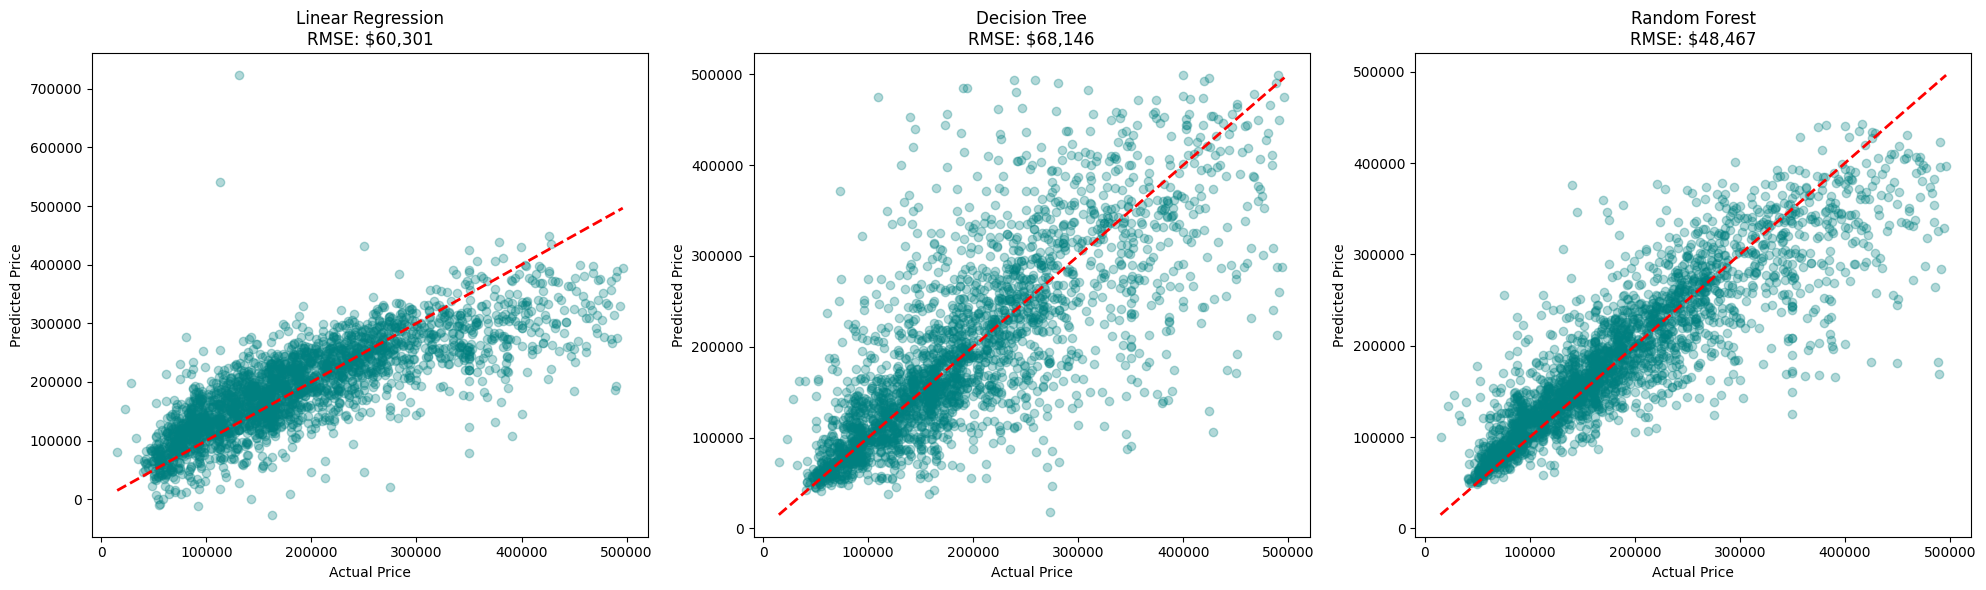

In [54]:

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
model_names = list(models.keys())

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_val_scaled)

    axes[i].scatter(y_val, y_pred, alpha=0.3, color='teal')
    axes[i].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)

    axes[i].set_title(f'{name}\nRMSE: ${np.sqrt(mean_squared_error(y_val, y_pred)):,.0f}')
    axes[i].set_xlabel('Actual Price')
    axes[i].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

In [55]:
# Hyperparameter Tuning



---
# 8️⃣ Final Evaluation & Submission 📈

---

### 🔗 ربط بالخطوة السابقة
عندنا أحسن موديل بعد الـ tuning — دلوقتي وقت الـ submission!

---

### 📖 النظرية
**خطوات الـ Final Submission:**

1. نتوقع على الـ test set
2. نعمل inverse transform للـ predictions (exp)
3. نعمل الـ submission file بالـ format المطلوب

**Residual Analysis:**
- نشوف الـ residuals (y - ŷ)
- لازم يكونوا randomly distributed
- لو فيه pattern → الموديل مش كويس كفاية

---

### 🤔 فكر قبل ما تكتب
- إيه الـ residuals وإزاي بتقراها؟
- ليه لازم تعمل exp للـ predictions؟
- إزاي تعرف إن الموديل كويس من الـ residual plot؟

---

### ⚠️ Common Mistakes
```
❌ غلط: تنسى تعمل exp للـ predictions.
✅ صح: لازم ترجع الـ log للـ price الأصلي.

❌ غلط: تقدم submission من غير ما تتأكد من الـ format.
✅ صح: قارن مع sample_submission.csv الأول.
```

---

### 🎯 المطلوب منك
1. استخدم أحسن موديل للـ prediction
2. اعمل inverse transform (expm1) للـ predictions
3. ارسم residual plot
4. اطبع الـ metrics النهائية (RMSE, MAE, R²)
5. اعمل submission.csv بالـ format الصحيح

In [19]:
# ============================================
# 📈 SECTION 8.1: Final Predictions
# ============================================

# كودك هنا ↓


In [20]:
# ============================================
# 📈 SECTION 8.2: Residual Analysis
# ============================================

# ارسم residual plot:
# - Scatter plot للـ residuals vs predicted values
# - Histogram للـ residuals

# كودك هنا ↓


**📊 فسّر النتيجة:**
```
- الـ residuals randomly distributed؟
- فيه pattern في الـ residual plot؟
- فيه outliers في الـ predictions؟
```
**تفسيرك هنا ↓**
```

```

In [21]:
# ============================================
# 📈 SECTION 8.3: Create Submission
# ============================================

# Format: Id,SalePrice
# مثال:
# 1461,169000.1
# 1462,187000.0

# كودك هنا ↓


---

# ✅ Final Checklist

قبل الـ submission، تأكد إنك عملت:

- [ ] Import كل المكتبات المطلوبة
- [ ] Load البيانات واكتشاف الـ missing values
- [ ] EDA كامل مع visualizations
- [ ] Feature Engineering (missing values, encoding, new features)
- [ ] Log transformation للـ target
- [ ] Train/Validation split
- [ ] جربت على الأقل 3 موديلات مختلفة
- [ ] Hyperparameter tuning
- [ ] Residual analysis
- [ ] Inverse transform للـ predictions
- [ ] Submission file بالـ format الصحيح
- [ ] جاوبت على كل الأسئلة

---

**🎉 مبروك! خلصت الـ notebook!**

**Good luck in the competition! 🍀**